In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/dataset project'
train = pd.read_csv(path + '/train.csv')
test = pd.read_csv(path + '/test.csv')
features= pd.read_csv(path + '/features.csv')
stores=pd.read_csv(path + '/stores.csv')

# clean data

check ไฟล์ที่โหลดมา

In [4]:
train.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [6]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [7]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


check missing values

In [8]:
print(train.isnull().sum())
print(features.isnull().sum())
print(stores.isnull().sum())
print(test.isnull().sum())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64
Store        0
Dept         0
Date         0
IsHoliday    0
dtype: int64


In [9]:
#markdown1-5 แทนด้วย0
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
features[markdown_cols] = features[markdown_cols].fillna(0)

In [10]:
#เพราะ CPI และ Unemployment ขึ้นกับพื้นที่/ภูมิภาคของ Store ดังนั้น วิธีที่ดีที่สุดคือเติมด้วย median ของแต่ละ store ในคอลัมน์นั้นๆ
features['CPI'] = features.groupby('Store')['CPI'].transform(lambda x: x.fillna(x.median()))
features['Unemployment'] = features.groupby('Store')['Unemployment'].transform(lambda x: x.fillna(x.median()))

In [11]:
print(features.isnull().sum())

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64


In [12]:
# แปลง Date ให้เป็น Datetime

train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])
features['Date'] = pd.to_datetime(features['Date'])

In [13]:
print(train.dtypes)
print(test.dtypes)
print(features.dtypes)
print(stores.dtypes)

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object
Store                 int64
Dept                  int64
Date         datetime64[ns]
IsHoliday              bool
dtype: object
Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object
Store     int64
Type     object
Size      int64
dtype: object


In [14]:
#ป้องกันก่อนส่งเข้า Tableau
train['IsHoliday'] = train['IsHoliday'].astype(int)
test['IsHoliday'] = test['IsHoliday'].astype(int)
features['IsHoliday'] = features['IsHoliday'].astype(int)

In [15]:
#merge file dataset
df = train.merge(features, on=['Store','Date'], how='left') \
          .merge(stores, on='Store', how='left')

In [16]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,A,151315
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,1,A,151315
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,A,151315
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,A,151315
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,A,151315


In [17]:
#แก้ column ซั้ํา

df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})
df = df.drop(columns=['IsHoliday_y'])

In [18]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  int64         
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [19]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size'],
      dtype='object')

In [20]:
df.to_csv("walmart_cleaned.csv", index=False)

# EDA

In [38]:
df.groupby('Type')['Size'].mean().round(0)


,Size
Type,
A,182231.0
B,101819.0
C,40536.0


In [39]:
df.groupby('Type')['Size'].describe()

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
A,215478.0,182231.285486,41534.529330,39690.0,158114.0,202505.0,203819.0,219622.0
B,163495.0,101818.735827,30921.779415,34875.0,93188.0,114533.0,123737.0,140167.0
C,42597.0,40535.725286,1194.434302,39690.0,39690.0,39910.0,41062.0,42988.0


In [40]:
df.groupby('Type')['Size'].agg(
    mean='mean',
    median='median',
    min='min',
    max='max'
).round(0)

,mean,median,min,max
Type,,,,
A,182231.0,202505.0,39690,219622
B,101819.0,114533.0,34875,140167
C,40536.0,39910.0,39690,42988


In [29]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

features[markdown_cols].isnull().sum()

,0
MarkDown1,0
MarkDown2,0
MarkDown3,0
MarkDown4,0
MarkDown5,0


In [30]:
missing_percent = features[markdown_cols].isnull().mean() * 100
missing_percent.sort_values(ascending=False)

,0
MarkDown1,0.0
MarkDown2,0.0
MarkDown3,0.0
MarkDown4,0.0
MarkDown5,0.0


In [31]:
(features[markdown_cols] > 0).sum()

,0
MarkDown1,4028
MarkDown2,2893
MarkDown3,3599
MarkDown4,3464
MarkDown5,4048


In [32]:
((features[markdown_cols] > 0).mean() * 100).round(2)

,0
MarkDown1,49.18
MarkDown2,35.32
MarkDown3,43.94
MarkDown4,42.30
MarkDown5,49.43


In [33]:
features['Date'] = pd.to_datetime(features['Date'])

In [34]:
features['Year'] = features['Date'].dt.year
features['Month'] = features['Date'].dt.month

In [35]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

md_month = (
    features
    .assign(active = features[markdown_cols].gt(0).any(axis=1))
    .groupby('Month')[markdown_cols]
    .apply(lambda x: (x > 0).mean() * 100)
)
md_month.round(2)

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Month,,,,,
1,66.67,66.48,55.37,55.00,66.67
2,49.72,49.72,43.19,45.42,50.00
3,55.43,35.43,48.77,48.52,55.56
4,44.44,30.99,40.49,37.65,44.32
5,52.81,24.84,49.15,44.05,52.94
6,52.68,41.57,40.92,45.10,52.94
7,44.32,35.93,41.23,37.16,44.44
8,37.95,27.86,36.07,35.38,38.46
9,30.60,18.80,26.32,26.84,30.77


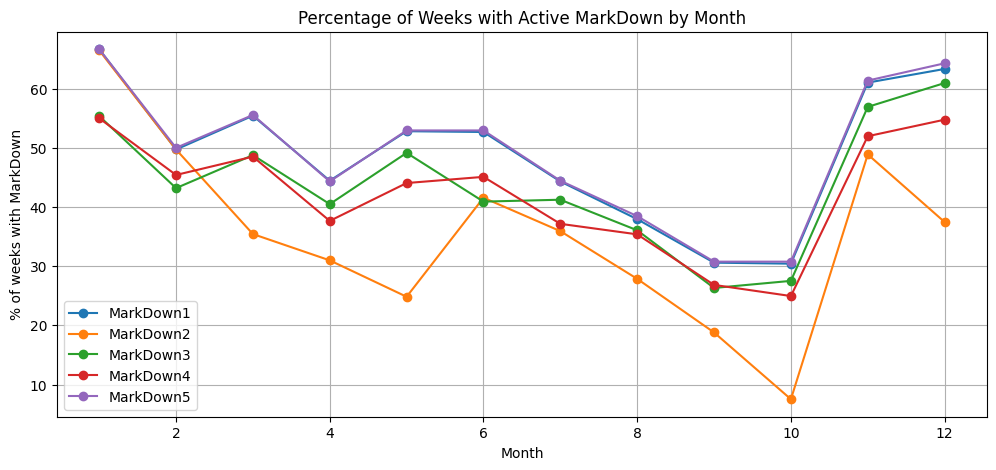

In [36]:
md_month.plot(
    figsize=(12,5),
    marker='o',
    title='Percentage of Weeks with Active MarkDown by Month'
)
plt.ylabel('% of weeks with MarkDown')
plt.xlabel('Month')
plt.grid(True)
plt.show()

In [37]:
md_year = (
    features
    .groupby('Year')[markdown_cols]
    .apply(lambda x: (x > 0).mean() * 100)
)

md_year.round(2)

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Year,,,,,
2010,0.00,0.00,0.00,0.00,0.00
2011,15.13,12.48,14.57,12.91,15.38
2012,99.49,66.37,88.72,85.90,99.96
2013,99.70,77.63,87.56,85.33,99.93


<Axes: xlabel='Date'>

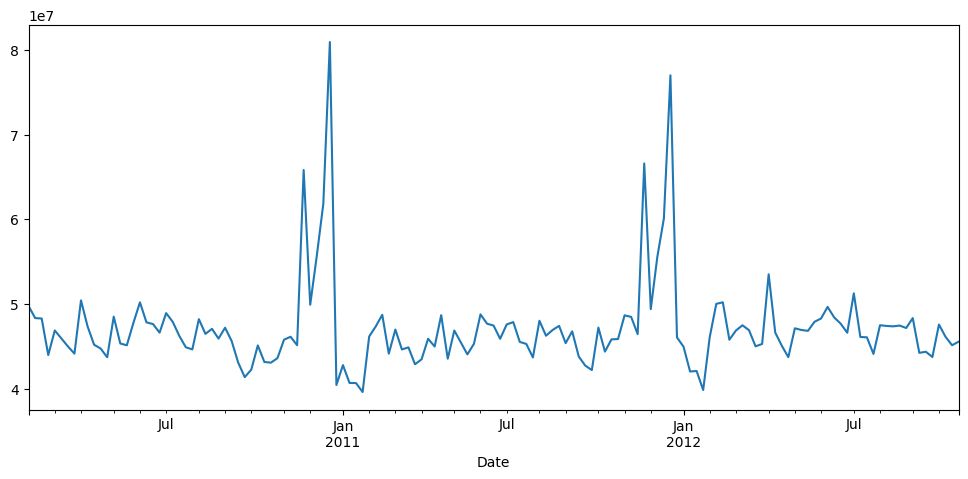

In [21]:
#Weekly sale trend
df.groupby('Date')['Weekly_Sales'].sum().plot(figsize=(12,5))

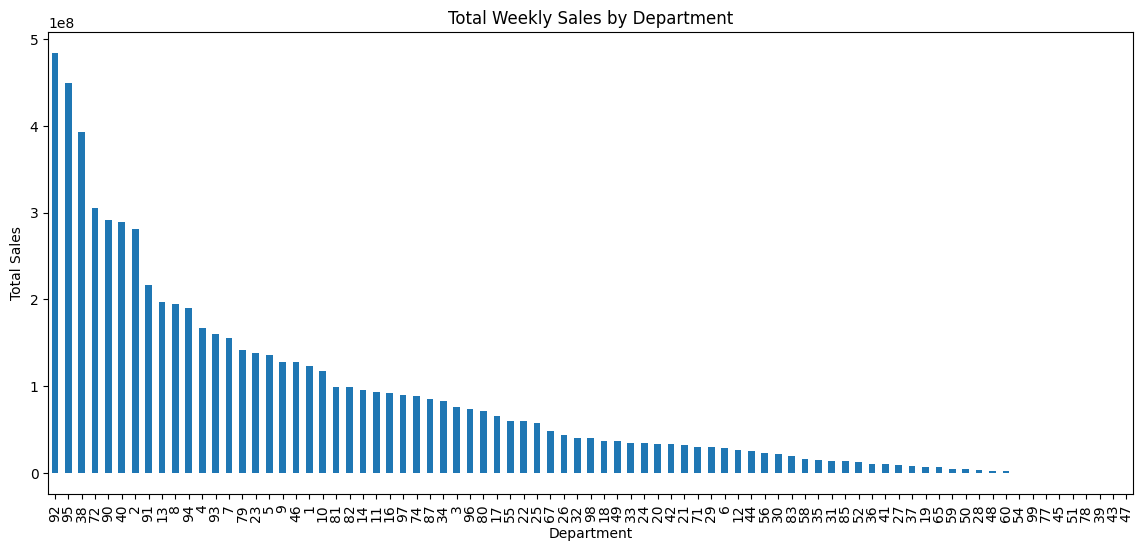

In [22]:
dept_total_sales = (
    df
    .groupby('Dept')['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))
dept_total_sales.plot(kind='bar')

plt.title('Total Weekly Sales by Department')
plt.xlabel('Department')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

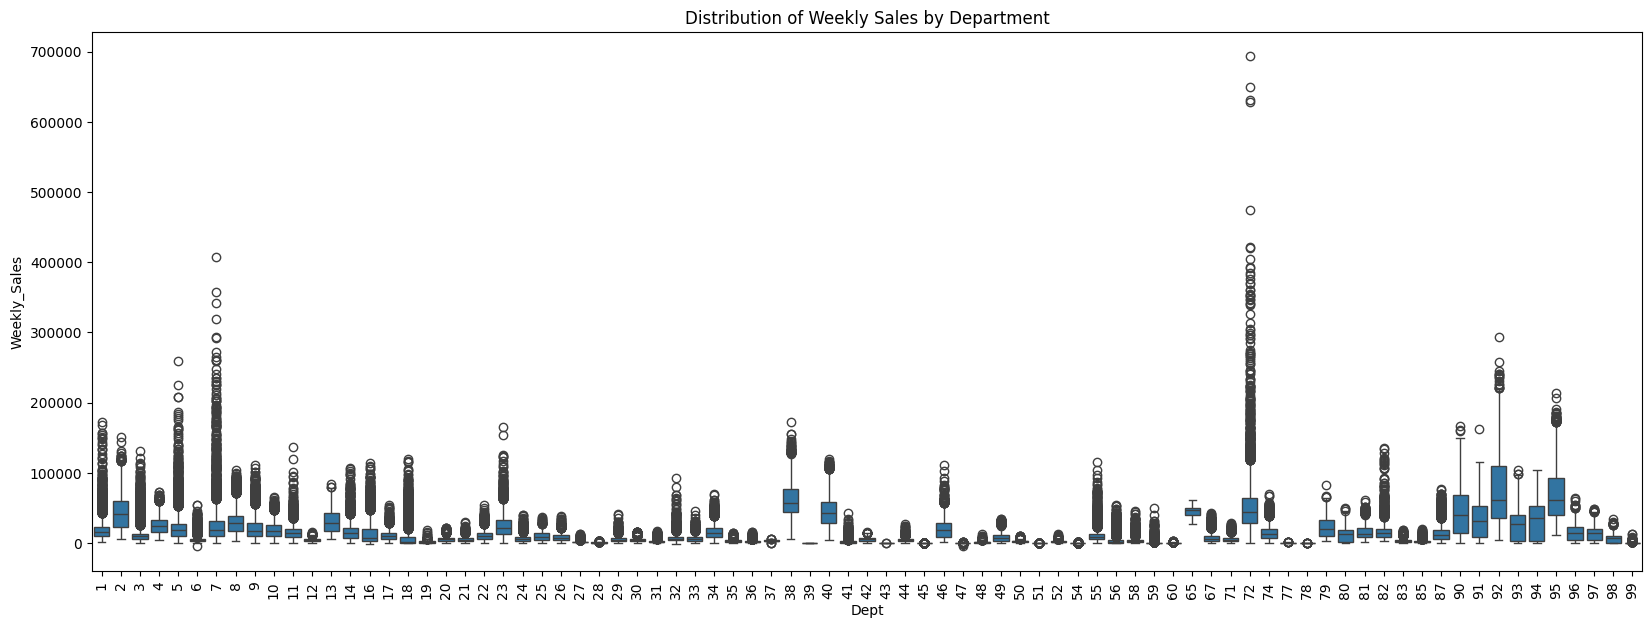

In [23]:
#ภาพรวมยอดขายรายสัปดาห์ของแต่ละ dept
plt.figure(figsize=(20,7))
sns.boxplot(
    x='Dept',
    y='Weekly_Sales',
    data=df
)
plt.title('Distribution of Weekly Sales by Department')
plt.xticks(rotation=90)
plt.show()

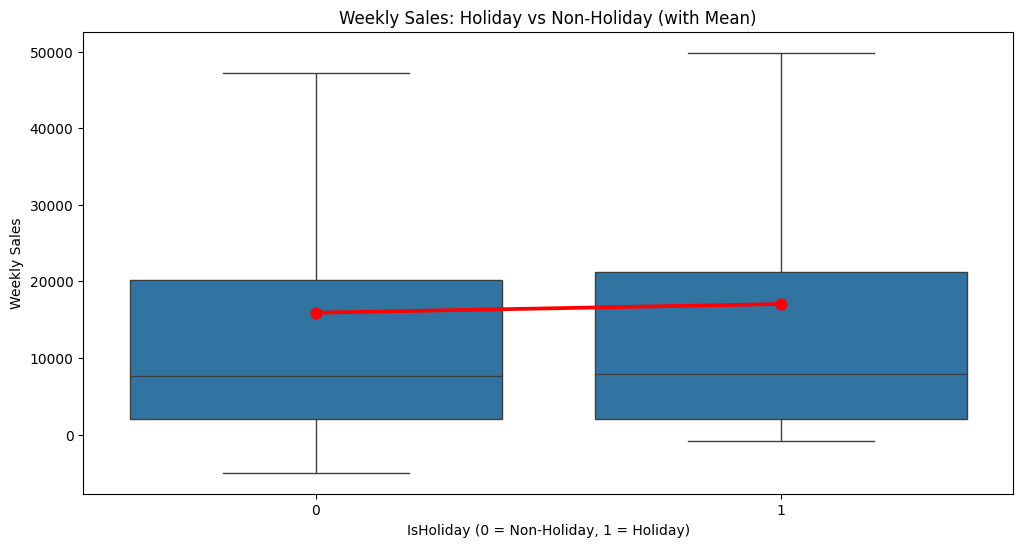

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='IsHoliday', y='Weekly_Sales', showfliers=False)
sns.pointplot(data=df, x='IsHoliday', y='Weekly_Sales', color='red', estimator=np.mean)

plt.title('Weekly Sales: Holiday vs Non-Holiday (with Mean)')
plt.xlabel('IsHoliday (0 = Non-Holiday, 1 = Holiday)')
plt.ylabel('Weekly Sales')

plt.show()

จากการวิเคราะห์และเปรียบเทียบยอดขายรายสัปดาห์ระหว่าง ช่วงวันหยุด (Holiday) และ วันปกติ (Non-Holiday) พบว่า:
 ระดับยอดขายโดยรวมของทั้งสองช่วงไม่ต่างกันมากนัก
ค่ามัธยฐาน (median) ของทั้งสองกลุ่มใกล้เคียงกัน แสดงว่ายอดขายปกติของร้านค้าไม่ได้ขึ้นอยู่กับวันหยุดอย่างชัดเจน
 อย่างไรก็ตามยอดขายช่วงวันหยุดมีแนวโน้มสูงกว่าเล็กน้อย
ซึ่งอาจเกิดจากปัจจัยเสริม เช่น

 • โปรโมชั่นตามฤดูกาล
 • เหตุการณ์พิเศษ (เช่น Black Friday)

 • พฤติกรรมของผู้บริโภคที่จับจ่ายมากขึ้นในช่วงเทศกาล

 • การกระจายตัวของข้อมูลช่วง Holiday กว้างกว่าเล็กน้อย
แสดงว่าบางช่วงเทศกาลอาจมีความผันผวนของยอดขายมากกว่าวันธรรมดา


จะทําให้เห็นชัดมากขึ้นในการทํา correlation matrix

In [25]:
dept_stats = (
    df.groupby('Dept')['Weekly_Sales']
      .agg(
          median_sales='median',
          q1=lambda x: x.quantile(0.25),
          q3=lambda x: x.quantile(0.75)
      )
      .sort_values('median_sales', ascending=False)
)

dept_stats.head(10)   # Top 10  สินค้าทํารายได้สูงสุด

,median_sales,q1,q3
Dept,,,
92,61816.77,35946.810,109575.0650
95,60774.39,39962.825,92642.9250
38,57336.65,43780.375,77059.8700
65,47281.16,39835.265,49958.3850
72,44312.36,28941.910,64283.6425
40,42717.87,28347.030,58991.8900
2,41412.61,22647.905,60195.3500
90,40535.79,14515.960,68516.4500
94,35003.70,3413.840,52887.4100


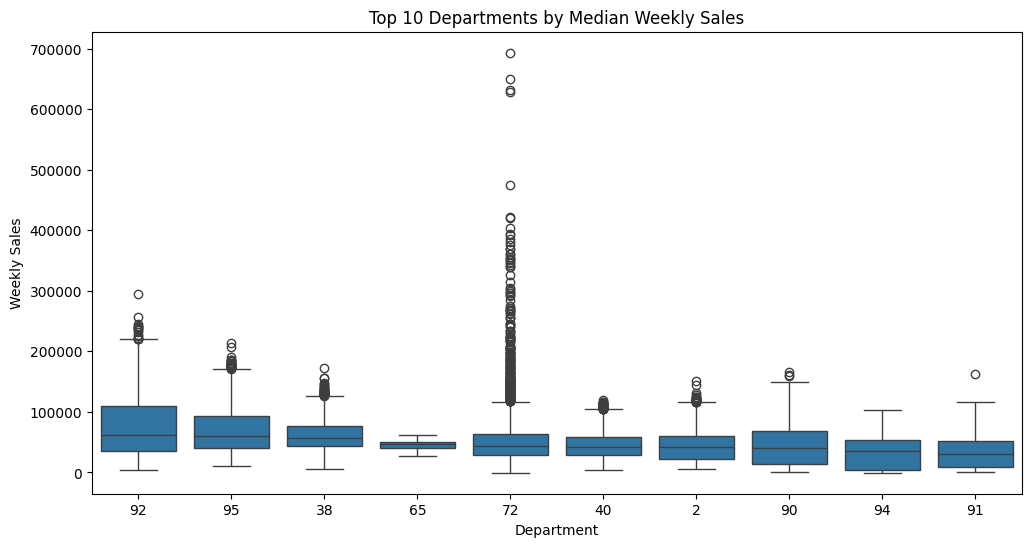

In [26]:
top10_depts = dept_stats.head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(
    x='Dept',
    y='Weekly_Sales',
    data=df[df['Dept'].isin(top10_depts)],
    order=top10_depts
)
plt.title('Top 10 Departments by Median Weekly Sales')
plt.xlabel('Department')
plt.ylabel('Weekly Sales')
plt.show()

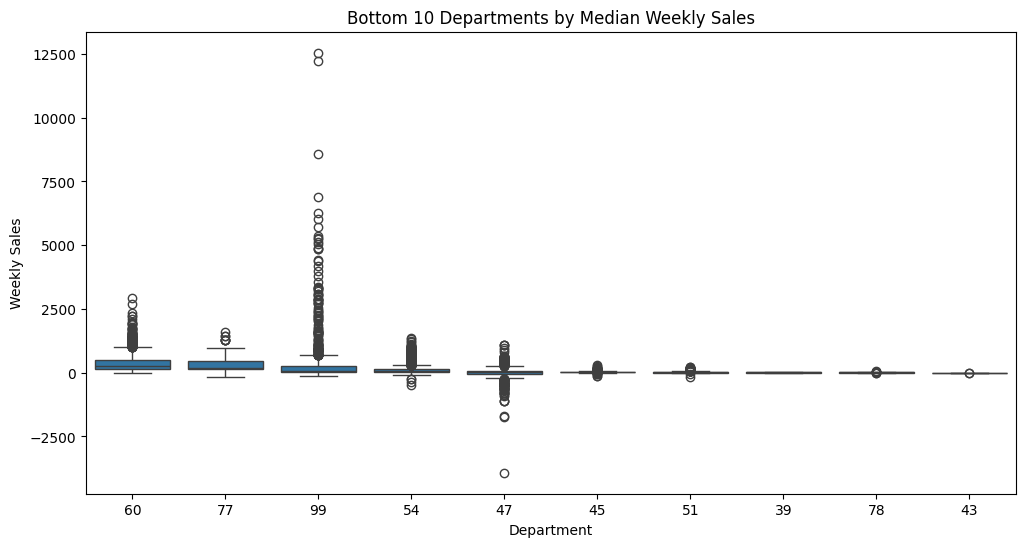

In [27]:
bottom10_depts = dept_stats.tail(10).index

plt.figure(figsize=(12,6))
sns.boxplot(
    x='Dept',
    y='Weekly_Sales',
    data=df[df['Dept'].isin(bottom10_depts)],
    order=bottom10_depts
)
plt.title('Bottom 10 Departments by Median Weekly Sales')
plt.xlabel('Department')
plt.ylabel('Weekly Sales')
plt.show()

Insight

เมื่อเรียงแผนกตามค่า median ของยอดขายรายสัปดาห์ พบว่าแผนกในกลุ่ม Top 10 มีระดับยอดขายปกติสูงกว่าแผนกอื่นอย่างชัดเจน และบางแผนกมีการกระจายของยอดขายค่อนข้างแคบ สะท้อนความสามารถในการสร้างยอดขายได้อย่างสม่ำเสมอ ในขณะที่แผนกในกลุ่ม Bottom 10 มีค่า median ต่ำ และมักพึ่งพายอดขายที่เกิดจากบางสัปดาห์เป็นหลัก แสดงให้เห็นถึงความแตกต่างของโครงสร้างรายได้ระหว่างแผนก

# Visaulize

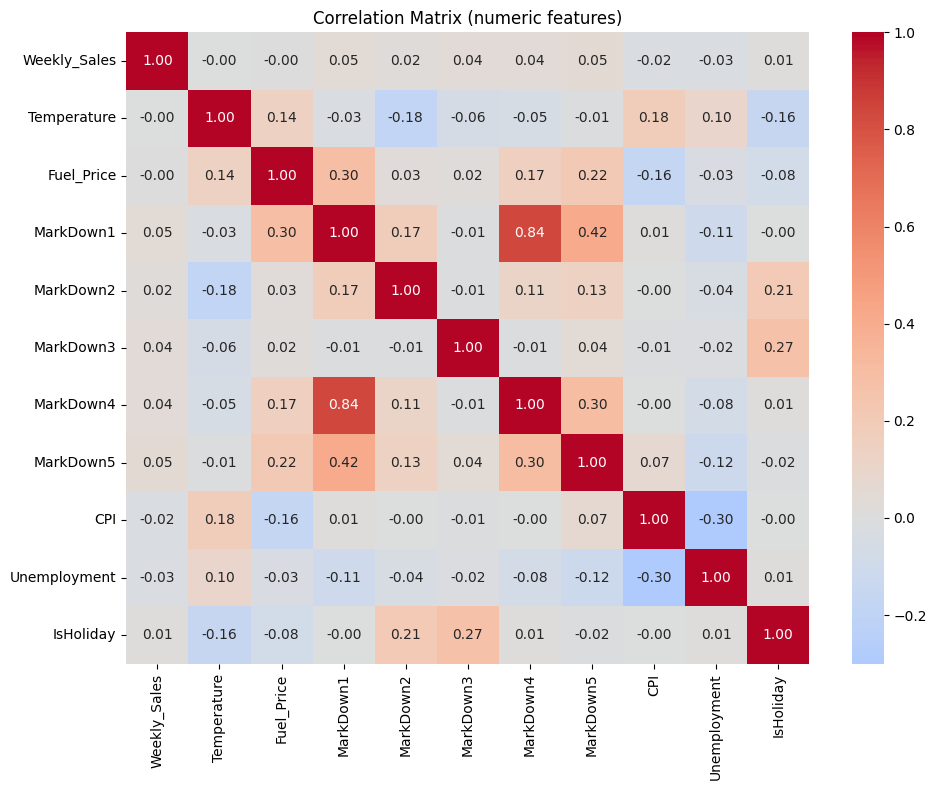

In [28]:
#วิเคราะห์เพิ่มเติมสร้าง features ที่สนใจ
num_cols = ['Weekly_Sales','Temperature','Fuel_Price','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment','IsHoliday']
# ถ้า MarkDown คอลัมน์บางอันเป็น 0 แค่ ignore — แต่ corr ยังคำนวณได้
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()

1. ยอดขายรายสัปดาห์ของ Walmart ไม่ได้ตอบสนองต่อปัจจัย numerical เช่นราคาน้ำมัน, CPI, หรืออุณหภูมิ โดยมีค่าสหสัมพันธ์น้อยกว่า 0.05 แสดงว่าโครงสร้างยอดขายถูกกำหนดโดยฤดูกาลและประเภทสินค้าเป็นหลัก

2. กลุ่มตัวแปร Promotion (MarkDown1–5) มีความสัมพันธ์กันสูง (0.30–0.84) สะท้อนว่ามักถูกใช้ร่วมกันเป็นแพ็กโปรโมชั่น แต่มีผลต่อยอดขายจริงเพียงเล็กน้อย

3. ตัวแปรเศรษฐกิจ CPI และ Unemployment มีความสัมพันธ์ทางลบค่อนข้างสูง (-0.30) แต่ไม่ส่งผลใด ๆ ต่อยอดขาย Walmart

4. ไม่พบตัวแปร numerical ใดที่สามารถใช้เป็นตัวชี้นำยอดขายได้อย่างมีนัยสำคัญ → สนับสนุนผล EDA ที่ว่า Dept และ Seasonality มีบทบาทสำคัญกว่า

# insight จากการทํา Correlation Matrix
จากการวิเคราะห์ Correlation Matrix พบว่าตัวแปรภายนอก เช่น สภาพอากาศ ราคาเชื้อเพลิง CPI อัตราว่างงาน วันหยุด และโปรโมชั่น Markdown มีความสัมพันธ์กับยอดขายในระดับต่ำมาก เมื่อเทียบกับความแตกต่างของยอดขายระหว่างแต่ละแผนก จึงสรุปได้ว่ายอดขายส่วนใหญ่ถูกกำหนดโดยตัวสินค้าและลักษณะของแต่ละ Department เองเป็นหลัก ไม่ได้ขึ้นกับปัจจัยภายนอกมากนัก

# จากInsight ดังกล่าว
ยอดขายของ Walmart ขึ้นอยู่กับคุณลักษณะของสินค้าและ Department มากกว่าปัจจัยภายนอก
เนื่องจากจากการวิเคราะห์พบว่า Department ที่ทำยอดขายสูงมีรูปแบบความต้องการเฉพาะตัวและมีพฤติกรรมยอดขายที่ชัดเจน ขณะที่ตัวแปรภายนอก เช่น อากาศ ราคาเชื้อเพลิง CPI อัตราว่างงาน หรือโปรโมชั่น มีผลเชิงสถิติต่อยอดขายเพียงเล็กน้อย

ดังนั้น กลยุทธ์สำคัญคือ การแบ่งกลุ่ม Department ตามประสิทธิภาพยอดขาย และจัดการแบบเฉพาะเจาะจง เช่น การเพิ่มสต็อกใน Dept ที่มีศักยภาพสูง การควบคุมต้นทุนใน Dept ที่ประสิทธิภาพต่ำ และใช้ข้อมูลเชิงลึกของแต่ละกลุ่มเพื่อวางแผนสินค้าและการตลาดอย่างตรงจุดมากขึ้น